In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [22]:
pd.set_option('display.max_columns', None)

In [23]:
df = pd.read_csv('gurgaon_properties_missing_value_imputation.csv')

In [24]:
df.shape

(3624, 18)

In [25]:
df.head()

,property_type,society,sector,price,price_per_sqft,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,house,independent,sector 11,4.00,19753.0,5,4,1,2.0,Moderately Old,2025.0,0,0,0,0,0,1,0
1,flat,indiabulls enigma,sector 110,3.30,9851.0,4,5,3,7.0,Relatively New,3032.0,0,1,0,0,0,1,101
2,flat,puri emerald bay,sector 104,2.30,9388.0,3,4,3+,10.0,Moderately Old,2217.0,0,1,0,0,0,1,101
3,house,nirvana cedar crest,sector 50,3.99,8867.0,4,5,3+,4.0,New Property,4500.0,0,1,0,1,0,0,112
4,flat,bptp terra,sector 37,1.45,8007.0,3,3,3,8.0,Relatively New,1711.0,0,0,0,0,0,1,149


In [74]:
train_df = df.drop(columns=['society','price_per_sqft'])

In [27]:
train_df.head()

,property_type,sector,price,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,house,sector 11,4.00,5,4,1,2.0,Moderately Old,2025.0,0,0,0,0,0,1,0
1,flat,sector 110,3.30,4,5,3,7.0,Relatively New,3032.0,0,1,0,0,0,1,101
2,flat,sector 104,2.30,3,4,3+,10.0,Moderately Old,2217.0,0,1,0,0,0,1,101
3,house,sector 50,3.99,4,5,3+,4.0,New Property,4500.0,0,1,0,1,0,0,112
4,flat,sector 37,1.45,3,3,3,8.0,Relatively New,1711.0,0,0,0,0,0,1,149


### luxury score

<Axes: xlabel='luxury_score'>

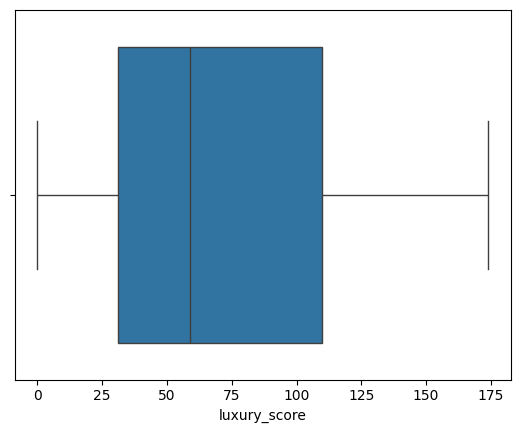

In [28]:
sns.boxplot(x=df['luxury_score'])

In [75]:
def categorize_luxury(score):
    if 0 <= score < 50:
        return "Low"
    elif 50 <= score < 150:
        return "Medium"
    elif 150 <= score <= 175:
        return "High"
    else:
        return None  # or "Undefined" or any other label for scores outside the defined bins

In [76]:
train_df['luxury_category'] = train_df['luxury_score'].apply(categorize_luxury)

In [77]:
train_df.head()

,property_type,sector,price,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,luxury_category
0,house,sector 11,4.00,5,4,1,2.0,Moderately Old,2025.0,0,0,0,0,0,1,0,Low
1,flat,sector 110,3.30,4,5,3,7.0,Relatively New,3032.0,0,1,0,0,0,1,101,Medium
2,flat,sector 104,2.30,3,4,3+,10.0,Moderately Old,2217.0,0,1,0,0,0,1,101,Medium
3,house,sector 50,3.99,4,5,3+,4.0,New Property,4500.0,0,1,0,1,0,0,112,Medium
4,flat,sector 37,1.45,3,3,3,8.0,Relatively New,1711.0,0,0,0,0,0,1,149,Medium


### floorNum

<Axes: ylabel='floorNum'>

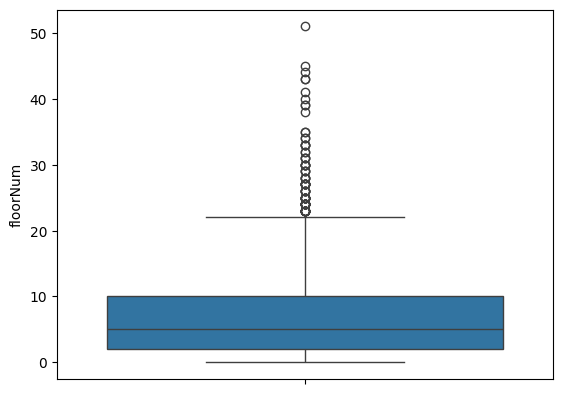

In [32]:
sns.boxplot(df['floorNum'])

In [78]:
def categorize_floor(floor):
    if 0 <= floor <= 2:
        return "Low Floor"
    elif 3 <= floor <= 10:
        return "Mid Floor"
    elif 11 <= floor <= 51:
        return "High Floor"
    else:
        return None  # or "Undefined" or any other label for floors outside the defined bins

In [81]:
train_df['floor_category'] = train_df['floorNum'].apply(categorize_floor)

In [82]:
train_df.head()

,property_type,sector,price,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,luxury_category,floor_category
0,house,sector 11,4.00,5,4,1,2.0,Moderately Old,2025.0,0,0,0,0,0,1,0,Low,Low Floor
1,flat,sector 110,3.30,4,5,3,7.0,Relatively New,3032.0,0,1,0,0,0,1,101,Medium,Mid Floor
2,flat,sector 104,2.30,3,4,3+,10.0,Moderately Old,2217.0,0,1,0,0,0,1,101,Medium,Mid Floor
3,house,sector 50,3.99,4,5,3+,4.0,New Property,4500.0,0,1,0,1,0,0,112,Medium,Mid Floor
4,flat,sector 37,1.45,3,3,3,8.0,Relatively New,1711.0,0,0,0,0,0,1,149,Medium,Mid Floor


In [83]:
train_df.drop(columns=['floorNum','luxury_score'],inplace=True)

In [84]:
train_df.head()

,property_type,sector,price,bedRoom,bathroom,balcony,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_category,floor_category
0,house,sector 11,4.00,5,4,1,Moderately Old,2025.0,0,0,0,0,0,1,Low,Low Floor
1,flat,sector 110,3.30,4,5,3,Relatively New,3032.0,0,1,0,0,0,1,Medium,Mid Floor
2,flat,sector 104,2.30,3,4,3+,Moderately Old,2217.0,0,1,0,0,0,1,Medium,Mid Floor
3,house,sector 50,3.99,4,5,3+,New Property,4500.0,0,1,0,1,0,0,Medium,Mid Floor
4,flat,sector 37,1.45,3,3,3,Relatively New,1711.0,0,0,0,0,0,1,Medium,Mid Floor


In [38]:
from sklearn.preprocessing import OrdinalEncoder

# Create a copy of the original data for label encoding
data_label_encoded = train_df.copy()

# Select categorical columns
cat_cols = data_label_encoded.select_dtypes(include=['object']).columns

oe = OrdinalEncoder()
data_label_encoded[cat_cols] = oe.fit_transform(data_label_encoded[cat_cols])


In [39]:
for col, categories in zip(cat_cols, oe.categories_):
    print(f"\n{col}")
    mapping = {category: i for i, category in enumerate(categories)}
    print(mapping)


property_type
{'flat': 0, 'house': 1}

sector
{'sector 1': 0, 'sector 10': 1, 'sector 102': 2, 'sector 103': 3, 'sector 104': 4, 'sector 105': 5, 'sector 106': 6, 'sector 107': 7, 'sector 108': 8, 'sector 109': 9, 'sector 11': 10, 'sector 110': 11, 'sector 111': 12, 'sector 112': 13, 'sector 113': 14, 'sector 12': 15, 'sector 13': 16, 'sector 14': 17, 'sector 15': 18, 'sector 17': 19, 'sector 2': 20, 'sector 21': 21, 'sector 22': 22, 'sector 23': 23, 'sector 24': 24, 'sector 25': 25, 'sector 26': 26, 'sector 27': 27, 'sector 28': 28, 'sector 3': 29, 'sector 30': 30, 'sector 31': 31, 'sector 33': 32, 'sector 36': 33, 'sector 37': 34, 'sector 38': 35, 'sector 39': 36, 'sector 4': 37, 'sector 40': 38, 'sector 41': 39, 'sector 42': 40, 'sector 43': 41, 'sector 45': 42, 'sector 46': 43, 'sector 47': 44, 'sector 48': 45, 'sector 49': 46, 'sector 5': 47, 'sector 50': 48, 'sector 51': 49, 'sector 52': 50, 'sector 53': 51, 'sector 54': 52, 'sector 55': 53, 'sector 56': 54, 'sector 57': 55, 'se

In [40]:
# Splitting the dataset into training and testing sets
X_label = data_label_encoded.drop('price', axis=1)
y_label = data_label_encoded['price']

In [41]:
X_label

,property_type,sector,bedRoom,bathroom,balcony,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_category,floor_category
0,1.0,10.0,5,4,1.0,0.0,2025.0,0,0,0,0,0,1,1.0,1.0
1,0.0,11.0,4,5,3.0,3.0,3032.0,0,1,0,0,0,1,2.0,2.0
2,0.0,4.0,3,4,4.0,0.0,2217.0,0,1,0,0,0,1,2.0,2.0
3,1.0,48.0,4,5,4.0,1.0,4500.0,0,1,0,1,0,0,2.0,2.0
4,0.0,34.0,3,3,3.0,3.0,1711.0,0,0,0,0,0,1,2.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3619,0.0,75.0,3,3,3.0,3.0,1735.0,0,0,0,0,0,1,1.0,2.0
3620,0.0,34.0,3,3,2.0,3.0,1163.0,0,0,0,0,0,1,1.0,2.0
3621,0.0,34.0,4,4,2.0,3.0,1765.0,0,0,0,0,0,1,2.0,2.0
3622,0.0,67.0,2,1,1.0,3.0,667.0,0,0,0,0,0,1,1.0,0.0


In [42]:
y_label

0       4.00
1       3.30
2       2.30
3       3.99
4       1.45
        ... 
3619    1.40
3620    1.00
3621    0.79
3622    0.60
3623    0.65
Name: price, Length: 3624, dtype: float64

### Technique 1 - Correlation Analysis

<Axes: >

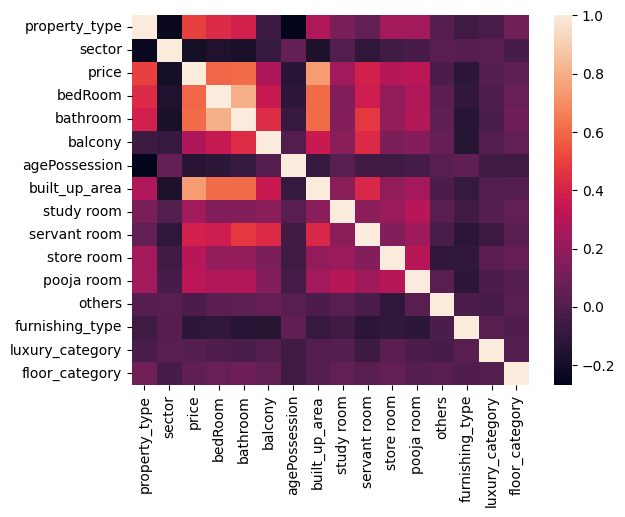

In [43]:
 sns.heatmap(data_label_encoded.corr())

In [44]:
fi_df1=data_label_encoded.corr()['price'].reset_index().rename(columns={'index':'feature','price':'corr_coeff'})
fi_df1

,feature,corr_coeff
0,property_type,0.495621
1,sector,-0.202967
2,price,1.000000
3,bedRoom,0.591270
4,bathroom,0.607778
5,balcony,0.272275
6,agePossession,-0.134324
7,built_up_area,0.747293
8,study room,0.241778
9,servant room,0.393330


### Technique 2 - Random Forest Feature Importance

In [45]:
from sklearn.ensemble import RandomForestRegressor

# Train a Random Forest regressor on label encoded data
rf_label = RandomForestRegressor(n_estimators=100, random_state=42)
rf_label.fit(X_label, y_label)

# Extract feature importance scores for label encoded data
fi_df2 = pd.DataFrame({
    'feature': X_label.columns,
    'rf_importance': rf_label.feature_importances_
}).sort_values(by='rf_importance', ascending=False)

fi_df2

,feature,rf_importance
6,built_up_area,0.650274
1,sector,0.101814
0,property_type,0.099845
2,bedRoom,0.027036
3,bathroom,0.025273
8,servant room,0.021226
5,agePossession,0.014549
4,balcony,0.012547
12,furnishing_type,0.009563
7,study room,0.008872


### Technique 3 - Gradient Boosting Feature importances

In [46]:
from sklearn.ensemble import GradientBoostingRegressor

# Train a Random Forest regressor on label encoded data
gb_label = GradientBoostingRegressor()
gb_label.fit(X_label, y_label)

# Extract feature importance scores for label encoded data
fi_df3 = pd.DataFrame({
    'feature': X_label.columns,
    'gb_importance': gb_label.feature_importances_
}).sort_values(by='gb_importance', ascending=False)

fi_df3

,feature,gb_importance
6,built_up_area,0.691442
1,sector,0.099121
0,property_type,0.096877
3,bathroom,0.034514
2,bedRoom,0.032095
8,servant room,0.025555
9,store room,0.005687
7,study room,0.005011
5,agePossession,0.004144
12,furnishing_type,0.002423


### Technique 4 - Permutation Importance

In [47]:
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split

X_train_label, X_test_label, y_train_label, y_test_label = train_test_split(X_label, y_label, test_size=0.2, random_state=42)

# Train a Random Forest regressor on label encoded data
rf_label = RandomForestRegressor(n_estimators=100, random_state=42)
rf_label.fit(X_train_label, y_train_label)

# Calculate Permutation Importance
perm_importance = permutation_importance(rf_label, X_test_label, y_test_label, n_repeats=30, random_state=42)

# Organize results into a DataFrame
fi_df4 = pd.DataFrame({
    'feature': X_label.columns,
    'permutation_importance': perm_importance.importances_mean
}).sort_values(by='permutation_importance', ascending=False)

fi_df4

,feature,permutation_importance
6,built_up_area,0.777841
0,property_type,0.201816
1,sector,0.140725
8,servant room,0.019283
2,bedRoom,0.013995
5,agePossession,0.009517
4,balcony,0.005500
7,study room,0.003304
13,luxury_category,0.002953
14,floor_category,0.002344


### Technique 5 - LASSO

In [48]:
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_label)

# Train a LASSO regression model
# We'll use a relatively small value for alpha (the regularization strength) for demonstration purposes
lasso = Lasso(alpha=0.01, random_state=42)
lasso.fit(X_scaled, y_label)

# Extract coefficients
fi_df5 = pd.DataFrame({
    'feature': X_label.columns,
    'lasso_coeff': lasso.coef_
}).sort_values(by='lasso_coeff', ascending=False)

fi_df5


,feature,lasso_coeff
6,built_up_area,1.504159
0,property_type,0.698961
3,bathroom,0.291203
9,store room,0.208097
8,servant room,0.186283
7,study room,0.176121
10,pooja room,0.078900
13,luxury_category,0.047097
2,bedRoom,0.027171
5,agePossession,-0.000000


### Technique 6 - RFE

In [49]:
from sklearn.feature_selection import RFE

# Initialize the base estimator
estimator = RandomForestRegressor()

# Apply RFE on the label-encoded and standardized training data
selector_label = RFE(estimator, n_features_to_select=X_label.shape[1], step=1)
selector_label = selector_label.fit(X_label, y_label)

# Get the selected features based on RFE
selected_features = X_label.columns[selector_label.support_]

# Extract the coefficients for the selected features from the underlying linear regression model
selected_coefficients = selector_label.estimator_.feature_importances_

# Organize the results into a DataFrame
fi_df6 = pd.DataFrame({
    'feature': selected_features,
    'rfe_score': selected_coefficients
}).sort_values(by='rfe_score', ascending=False)

fi_df6


,feature,rfe_score
6,built_up_area,0.643291
1,sector,0.107638
0,property_type,0.104716
2,bedRoom,0.025497
3,bathroom,0.024381
8,servant room,0.021319
5,agePossession,0.014285
4,balcony,0.012142
12,furnishing_type,0.008506
7,study room,0.008080


### Technique 7 - Linear Regression Weights

In [50]:
# Train a linear regression model on the label-encoded and standardized training data
from sklearn.linear_model import LinearRegression
lin_reg = LinearRegression()
lin_reg.fit(X_scaled, y_label)

# Extract coefficients
fi_df7 = pd.DataFrame({
    'feature': X_label.columns,
    'reg_coeffs': lin_reg.coef_
}).sort_values(by='reg_coeffs', ascending=False)

fi_df7


,feature,reg_coeffs
6,built_up_area,1.506751
0,property_type,0.698809
3,bathroom,0.297886
9,store room,0.212387
8,servant room,0.196363
7,study room,0.184562
10,pooja room,0.081936
13,luxury_category,0.058053
2,bedRoom,0.030769
5,agePossession,0.002801


    ### Technique 8 - SHAP

In [51]:
!pip install shap

Defaulting to user installation because normal site-packages is not writeable


In [52]:
import shap

# Compute SHAP values using the trained Random Forest model
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_label, y_label)

explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_label)

# Summing the absolute SHAP values across all samples to get an overall measure of feature importance
shap_sum = np.abs(shap_values).mean(axis=0)

shap_values


array([[ 1.03773615e+00, -3.08559349e-01,  9.88028985e-02, ...,
        -5.85558632e-02, -2.16637266e-02, -4.85274463e-02],
       [-8.34088944e-01, -1.54902653e-01, -4.10033465e-02, ...,
        -4.27540889e-02,  2.63105239e-03, -1.50211741e-02],
       [-5.25252581e-01, -2.26487359e-01, -3.18434857e-02, ...,
        -2.42041229e-02,  5.66287657e-03, -1.97633838e-02],
       ...,
       [-3.92654377e-01, -1.58942407e-01,  7.19346877e-02, ...,
        -1.64040064e-02, -1.00753745e-03, -3.23857427e-02],
       [-1.58299758e-01,  9.19119592e-02, -6.11140559e-02, ...,
        -1.14363335e-02, -5.49497460e-03,  3.95494282e-02],
       [-1.95521074e-01, -5.23367186e-01, -5.01791115e-02, ...,
        -1.22307562e-02,  1.04119342e-02, -5.99959411e-03]],
      shape=(3624, 15))

In [53]:
fi_df8 = pd.DataFrame({
    'feature': X_label.columns,
    'SHAP_score': np.abs(shap_values).mean(axis=0)
}).sort_values(by='SHAP_score', ascending=False)

fi_df8 

,feature,SHAP_score
6,built_up_area,1.254714
0,property_type,0.474869
1,sector,0.373735
3,bathroom,0.109122
8,servant room,0.101768
2,bedRoom,0.056276
4,balcony,0.042034
12,furnishing_type,0.027731
5,agePossession,0.027152
14,floor_category,0.024461


In [54]:
final_fi_df = fi_df1.merge(fi_df2,on='feature').merge(fi_df3,on='feature').merge(fi_df4,on='feature').merge(fi_df5,on='feature').merge(fi_df6,on='feature').merge(fi_df7,on='feature').merge(fi_df8,on='feature').set_index('feature')

In [55]:
final_fi_df

,corr_coeff,rf_importance,gb_importance,permutation_importance,lasso_coeff,rfe_score,reg_coeffs,SHAP_score
feature,,,,,,,,
property_type,0.495621,0.099845,0.096877,0.201816,0.698961,0.104716,0.698809,0.474869
sector,-0.202967,0.101814,0.099121,0.140725,-0.046359,0.107638,-0.055177,0.373735
bedRoom,0.591270,0.027036,0.032095,0.013995,0.027171,0.025497,0.030769,0.056276
bathroom,0.607778,0.025273,0.034514,0.001506,0.291203,0.024381,0.297886,0.109122
balcony,0.272275,0.012547,0.002076,0.005500,-0.021635,0.012142,-0.044574,0.042034
agePossession,-0.134324,0.014549,0.004144,0.009517,-0.000000,0.014285,0.002801,0.027152
built_up_area,0.747293,0.650274,0.691442,0.777841,1.504159,0.643291,1.506751,1.254714
study room,0.241778,0.008872,0.005011,0.003304,0.176121,0.008080,0.184562,0.019084
servant room,0.393330,0.021226,0.025555,0.019283,0.186283,0.021319,0.196363,0.101768


In [56]:
# normalize the score
final_fi_df = final_fi_df.divide(final_fi_df.sum(axis=0), axis=1)

In [57]:
final_fi_df[['rf_importance','gb_importance','permutation_importance','rfe_score','SHAP_score']].mean(axis=1).sort_values(ascending=False)

feature
built_up_area      0.627390
property_type      0.131738
sector             0.114868
bathroom           0.025621
servant room       0.024856
bedRoom            0.023706
agePossession      0.010337
balcony            0.009575
furnishing_type    0.006595
study room         0.006447
floor_category     0.004896
luxury_category    0.004642
store room         0.004299
pooja room         0.003313
others             0.001717
dtype: float64

In [58]:
# to drop pooja room, study room, others
X_label

,property_type,sector,bedRoom,bathroom,balcony,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_category,floor_category
0,1.0,10.0,5,4,1.0,0.0,2025.0,0,0,0,0,0,1,1.0,1.0
1,0.0,11.0,4,5,3.0,3.0,3032.0,0,1,0,0,0,1,2.0,2.0
2,0.0,4.0,3,4,4.0,0.0,2217.0,0,1,0,0,0,1,2.0,2.0
3,1.0,48.0,4,5,4.0,1.0,4500.0,0,1,0,1,0,0,2.0,2.0
4,0.0,34.0,3,3,3.0,3.0,1711.0,0,0,0,0,0,1,2.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3619,0.0,75.0,3,3,3.0,3.0,1735.0,0,0,0,0,0,1,1.0,2.0
3620,0.0,34.0,3,3,2.0,3.0,1163.0,0,0,0,0,0,1,1.0,2.0
3621,0.0,34.0,4,4,2.0,3.0,1765.0,0,0,0,0,0,1,2.0,2.0
3622,0.0,67.0,2,1,1.0,3.0,667.0,0,0,0,0,0,1,1.0,0.0


In [59]:
# with all the cols
from sklearn.model_selection import cross_val_score

rf = RandomForestRegressor(n_estimators=100, random_state=42)

scores = cross_val_score(rf, X_label, y_label, cv=5, scoring='r2')

In [60]:
scores.mean()

np.float64(0.8013301323072117)

In [61]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)

scores = cross_val_score(rf, X_label.drop(columns=['pooja room', 'study room', 'others']), y_label, cv=5, scoring='r2')

In [62]:
scores.mean()

np.float64(0.8034013424086581)

In [63]:
export_df = X_label.drop(columns=['pooja room', 'study room', 'others'])
export_df['price'] = y_label 

In [64]:
export_df

,property_type,sector,bedRoom,bathroom,balcony,agePossession,built_up_area,servant room,store room,furnishing_type,luxury_category,floor_category,price
0,1.0,10.0,5,4,1.0,0.0,2025.0,0,0,1,1.0,1.0,4.00
1,0.0,11.0,4,5,3.0,3.0,3032.0,1,0,1,2.0,2.0,3.30
2,0.0,4.0,3,4,4.0,0.0,2217.0,1,0,1,2.0,2.0,2.30
3,1.0,48.0,4,5,4.0,1.0,4500.0,1,0,0,2.0,2.0,3.99
4,0.0,34.0,3,3,3.0,3.0,1711.0,0,0,1,2.0,2.0,1.45
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3619,0.0,75.0,3,3,3.0,3.0,1735.0,0,0,1,1.0,2.0,1.40
3620,0.0,34.0,3,3,2.0,3.0,1163.0,0,0,1,1.0,2.0,1.00
3621,0.0,34.0,4,4,2.0,3.0,1765.0,0,0,1,2.0,2.0,0.79
3622,0.0,67.0,2,1,1.0,3.0,667.0,0,0,1,1.0,0.0,0.60


In [71]:
export_df.to_csv('gurgaon_properties_feature_selection.csv', index=False)

In [85]:
train_df

,property_type,sector,price,bedRoom,bathroom,balcony,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_category,floor_category
0,house,sector 11,4.00,5,4,1,Moderately Old,2025.0,0,0,0,0,0,1,Low,Low Floor
1,flat,sector 110,3.30,4,5,3,Relatively New,3032.0,0,1,0,0,0,1,Medium,Mid Floor
2,flat,sector 104,2.30,3,4,3+,Moderately Old,2217.0,0,1,0,0,0,1,Medium,Mid Floor
3,house,sector 50,3.99,4,5,3+,New Property,4500.0,0,1,0,1,0,0,Medium,Mid Floor
4,flat,sector 37,1.45,3,3,3,Relatively New,1711.0,0,0,0,0,0,1,Medium,Mid Floor
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3619,flat,sector 77,1.40,3,3,3,Relatively New,1735.0,0,0,0,0,0,1,Low,Mid Floor
3620,flat,sector 37,1.00,3,3,2,Relatively New,1163.0,0,0,0,0,0,1,Low,Mid Floor
3621,flat,sector 37,0.79,4,4,2,Relatively New,1765.0,0,0,0,0,0,1,Medium,Mid Floor
3622,flat,sector 69,0.60,2,1,1,Relatively New,667.0,0,0,0,0,0,1,Low,High Floor


In [86]:
train_df.drop(columns=['pooja room', 'study room', 'others'],inplace=True)

In [87]:
train_df

,property_type,sector,price,bedRoom,bathroom,balcony,agePossession,built_up_area,servant room,store room,furnishing_type,luxury_category,floor_category
0,house,sector 11,4.00,5,4,1,Moderately Old,2025.0,0,0,1,Low,Low Floor
1,flat,sector 110,3.30,4,5,3,Relatively New,3032.0,1,0,1,Medium,Mid Floor
2,flat,sector 104,2.30,3,4,3+,Moderately Old,2217.0,1,0,1,Medium,Mid Floor
3,house,sector 50,3.99,4,5,3+,New Property,4500.0,1,0,0,Medium,Mid Floor
4,flat,sector 37,1.45,3,3,3,Relatively New,1711.0,0,0,1,Medium,Mid Floor
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3619,flat,sector 77,1.40,3,3,3,Relatively New,1735.0,0,0,1,Low,Mid Floor
3620,flat,sector 37,1.00,3,3,2,Relatively New,1163.0,0,0,1,Low,Mid Floor
3621,flat,sector 37,0.79,4,4,2,Relatively New,1765.0,0,0,1,Medium,Mid Floor
3622,flat,sector 69,0.60,2,1,1,Relatively New,667.0,0,0,1,Low,High Floor


In [88]:
train_df.to_csv('gurgaon_properties_feature_selectionV2.csv', index=False)